# Identifying Flooded Areas with Sentinel-1 Data

openEO can be used for a wide range of Earth Observation (EO) applications, from simple to advanced workflows. In this notebook, we will demonstrate a simple workflow to use openEO for **identifying flooded areas using Sentinel-1 data**.

The workflow compares radar imagery before and after a flood event to identify newly inundated areas.


Let us start by connecting to the Copernicus Data Space Ecosystem (CDSE) backend, which provides access to Sentinel-1 dataset and the necessary processing capabilities.

In [1]:
import openeo

connection = openeo.connect("https://openeo.dataspace.copernicus.eu/").authenticate_oidc()

Authenticated using refresh token.


For this case study, we will focus on a region along the border between the Czech Republic and Poland that was affected by severe flooding in September 2024, caused by [Storm Boris](http://nl.wikipedia.org/wiki/Boris_(cycloon)). It caused significant damage in the Czech Republic, Poland, and Austria. In this case study, we will explore a specific location in the Czech Republic. 

In [2]:
spatial_extent = {"west": 16.7, "south": 50.08, "east": 18.0, "north": 50.5}

# plot spatial extent
import folium
map = folium.Map(
    location=[(spatial_extent["south"] + spatial_extent["north"]) / 2, (spatial_extent["west"] + spatial_extent["east"]) / 2], 
    zoom_start=10
    )
folium.Rectangle(
    bounds=[[spatial_extent["south"], spatial_extent["west"]], [spatial_extent["north"], spatial_extent["east"]]],
    color='blue',
    fill=True,
    fill_color='blue',
    fill_opacity=0.2
).add_to(map)
map


We start by loading the Sentinel-1 GRD data from the CDSE backend for our area of interest and time range, selecting the relevant bands for flood detection (VV and VH polarisations). 

Next, using built-in openEO functions such as `sar_backscatter`, we can easily compute the backscatter coefficients needed for flood detection without writing complex code for data handling and processing.

In [3]:
before_cube = connection.load_collection(        
                            "SENTINEL1_GRD",        
                            spatial_extent=spatial_extent,        
                            temporal_extent=["2024-08-25", "2024-09-09"],        
                            bands=["VV"],        
                            properties={"sat:orbit_state": lambda x: x == "descending"})    
# applying radiometric corrections
before_cube = before_cube.sar_backscatter(coefficient="sigma0-ellipsoid")

To reduce noise and improve flood detection accuracy, we apply openEO's `median_time` process, which computes the median backscatter value for each pixel across the time series.

In [4]:
# temporal reduction to get a single image for the before period
before_median = before_cube.median_time()    

Similarly, the median backscatter values for post-flood is calculated as shown below:

In [5]:
after_cube = connection.load_collection(        
                            "SENTINEL1_GRD",        
                            spatial_extent=spatial_extent,        
                            temporal_extent=["2024-09-11", "2024-09-25"],        
                            bands=["VV"],        
                            properties={"sat:orbit_state": lambda x: x == "descending"}) 
after_cube = after_cube.sar_backscatter(coefficient="sigma0-ellipsoid")    
after_median = after_cube.median_time()    


To identify flooded areas, we can compute the difference of the median backscatter values before and after the flood event. A significant decrease in backscatter (e.g., a difference below a certain threshold) indicates potential flooding.

A binary mask is created using the `if_` process in openEO, where pixels with a backscatter difference below the threshold are classified as flooded (1), and others as not flooded (0).

Please note that the threshold can be adjusted based on the specific characteristics of the area and the flood event. In this case, we will use a threshold of -3 dB.

In [6]:
ratio = after_median / before_median
threshold = -3    
flooded = ratio.apply(
    lambda x: openeo.processes.if_(
        10 * openeo.processes.log(x, base=10) < threshold,
        1,  # Flooded
        0   # Not flooded
    )
)
flooded

Please note that while this looks like an actual calculation, real data processing still needs to be done. At this point, the **flood_change_result** object is just an abstract representation of our algorithm under construction. The mathematical operators we used here are syntactic sugar for compactly expressing this part of the algorithm.

Finally, to trigger an actual execution (on the backend), we have to explicitly send the above representation to the backend. We can do this either synchronously(simple download) or using the batch-job-based method. 

Most of the simple, basic openEO usage examples show synchronous downloading of results. Synchronous downloads are handy for quick experimentation on small data cubes.

This only works properly if the processing doesn’t take too long and is focused on a smaller area of interest. However, you have to use batch jobs for the heavier work (larger regions of interest, larger time series, more intensive processing).

For more information on using batch-job in openEO, visit [here](https://open-eo.github.io/openeo-python-client/batch_jobs.html).

In [7]:
openeo_job = flooded.create_job(
                    title="Flood Detection with Sentinel-1",
                    )
openeo_job.start_and_wait()

0:00:00 Job 'j-2604201257004b0e8186e322dc28eec6': send 'start'
0:00:22 Job 'j-2604201257004b0e8186e322dc28eec6': created (progress 0%)
0:00:27 Job 'j-2604201257004b0e8186e322dc28eec6': created (progress 0%)
0:00:33 Job 'j-2604201257004b0e8186e322dc28eec6': created (progress 0%)
0:00:41 Job 'j-2604201257004b0e8186e322dc28eec6': queued (progress 0%)
0:00:51 Job 'j-2604201257004b0e8186e322dc28eec6': queued (progress 0%)
0:01:04 Job 'j-2604201257004b0e8186e322dc28eec6': queued (progress 0%)
0:01:19 Job 'j-2604201257004b0e8186e322dc28eec6': queued (progress 0%)
0:01:38 Job 'j-2604201257004b0e8186e322dc28eec6': queued (progress 0%)
0:02:02 Job 'j-2604201257004b0e8186e322dc28eec6': running (progress N/A)
0:02:32 Job 'j-2604201257004b0e8186e322dc28eec6': running (progress N/A)
0:03:10 Job 'j-2604201257004b0e8186e322dc28eec6': running (progress N/A)
0:03:57 Job 'j-2604201257004b0e8186e322dc28eec6': running (progress N/A)
0:04:56 Job 'j-2604201257004b0e8186e322dc28eec6': running (progress N/A)
0

<BatchJob job_id='j-2604201257004b0e8186e322dc28eec6'>

In [8]:
results = openeo_job.get_results()
results.download_files("flooded_region/")

[WindowsPath('flooded_region/openEO.tif'),
 WindowsPath('flooded_region/job-results.json')]

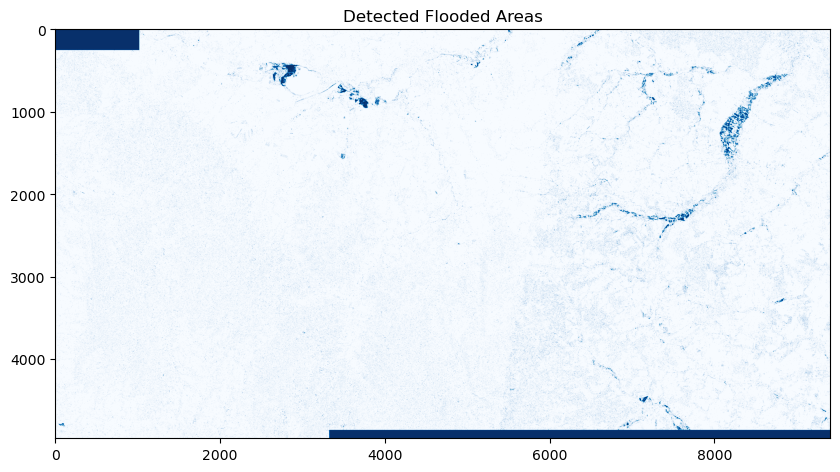

In [17]:
import rasterio
import matplotlib.pyplot as plt


with rasterio.open("flooded_region/openEO.tif") as src:
    flood_change_data = src.read(1)  

plt.figure(figsize=(10, 10))
plt.tight_layout()
plt.imshow(flood_change_data.astype(bool), cmap="Blues", vmin=0, vmax=1)
plt.title("Detected Flooded Areas")
plt.show()

These generated maps could serve as important inputs for emergency response teams, urban planners, and environmental scientists to assess flood impacts and plan mitigation strategies within few hours after the event, without needing to download and process large datasets locally.